# TP1 — Clasificación del Dataset Iris
## Ignacio Aracena - Tomas Arizu | Ciencia de Datos 

Análisis del dataset Iris con el objetivo de clasificar tres especies de flores (*Iris setosa*, *Iris versicolor* e *Iris virginica*) a partir de cuatro variables morfológicas.

**Contenido:**
1. Carga y Exploración de Datos (EDA)
2. Análisis de Componentes Principales (PCA)
3. Feature Engineering
4. Preparación para el Modelado
5. Experimentos de Modelado
6. Curvas ROC
7. Tabla Comparativa Final

---
## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_curve, auc

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print('XGBoost disponible')
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost no disponible. Instalar con: pip install xgboost')

CLASS_NAMES = ['setosa', 'versicolor', 'virginica']

# lista para guardar resultados de cada modelo
resultados = []

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


XGBoost disponible


---
## 2. Carga y Exploración de Datos (EDA)

### 2.1 Carga del dataset

In [2]:
iris = load_iris()

iris_df = pd.DataFrame(
    data=iris.data,
    columns=['longitud_sepalo', 'ancho_sepalo', 'longitud_petalo', 'ancho_petalo']
)
iris_df['target']  = iris.target
iris_df['species'] = iris_df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print('Dimensiones del dataset:', iris_df.shape)
display(iris_df.describe().T.round(2))
display(iris_df.head())

Dimensiones del dataset: (150, 6)


,count,mean,std,min,25%,50%,75%,max
longitud_sepalo,150.0,5.84,0.83,4.3,5.1,5.80,6.4,7.9
ancho_sepalo,150.0,3.06,0.44,2.0,2.8,3.00,3.3,4.4
longitud_petalo,150.0,3.76,1.77,1.0,1.6,4.35,5.1,6.9
ancho_petalo,150.0,1.20,0.76,0.1,0.3,1.30,1.8,2.5
target,150.0,1.00,0.82,0.0,0.0,1.00,2.0,2.0


,longitud_sepalo,ancho_sepalo,longitud_petalo,ancho_petalo,target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


El dataset tiene **150 muestras** y **4 variables numéricas** en centímetros. Las variables del pétalo tienen mayor rango y desviación estándar, lo que anticipa mayor poder discriminativo.

### 2.2 Balance de clases

Cantidad de muestras por especie:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


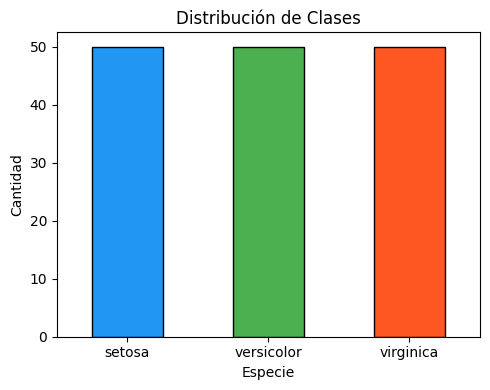

In [3]:
print('Cantidad de muestras por especie:')
print(iris_df['species'].value_counts())

plt.figure(figsize=(5, 4))
iris_df['species'].value_counts().plot(kind='bar', color=['#2196F3', '#4CAF50', '#FF5722'], edgecolor='black')
plt.title('Distribución de Clases')
plt.xlabel('Especie')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

El dataset está **perfectamente balanceado**: 50 muestras por especie. Esto permite usar accuracy como métrica confiable sin necesidad de técnicas de balanceo.

### 2.3 Histogramas con curva de densidad (KDE)

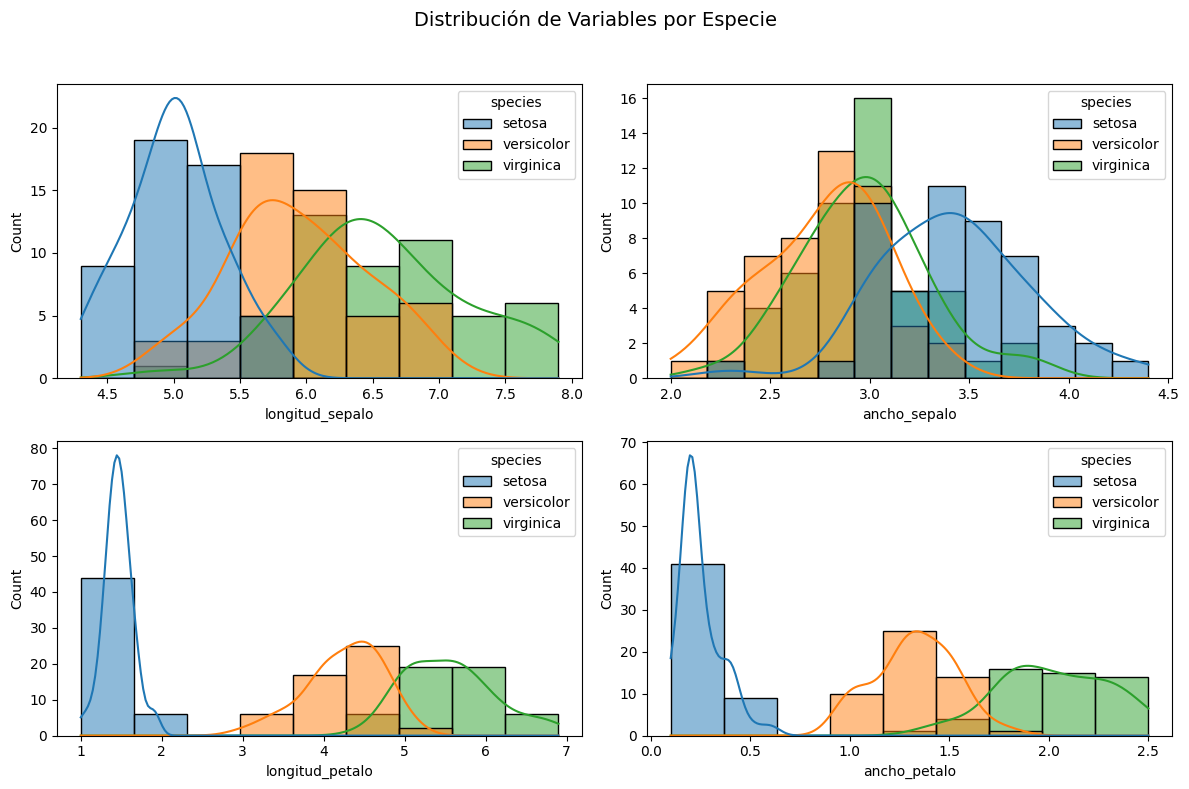

In [4]:
features = ['longitud_sepalo', 'ancho_sepalo', 'longitud_petalo', 'ancho_petalo']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribución de Variables por Especie', fontsize=14)

sns.histplot(data=iris_df, x='longitud_sepalo', hue='species', kde=True, ax=axes[0, 0])
sns.histplot(data=iris_df, x='ancho_sepalo',    hue='species', kde=True, ax=axes[0, 1])
sns.histplot(data=iris_df, x='longitud_petalo', hue='species', kde=True, ax=axes[1, 0])
sns.histplot(data=iris_df, x='ancho_petalo',    hue='species', kde=True, ax=axes[1, 1])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

- **longitud_petalo** y **ancho_petalo**: distribución claramente bimodal — *setosa* forma un grupo separado.
- **longitud_sepalo** y **ancho_sepalo**: mayor superposición entre las tres especies.

Las variables del **pétalo son más discriminativas** que las del sépalo.

### 2.4 Scatter Plots

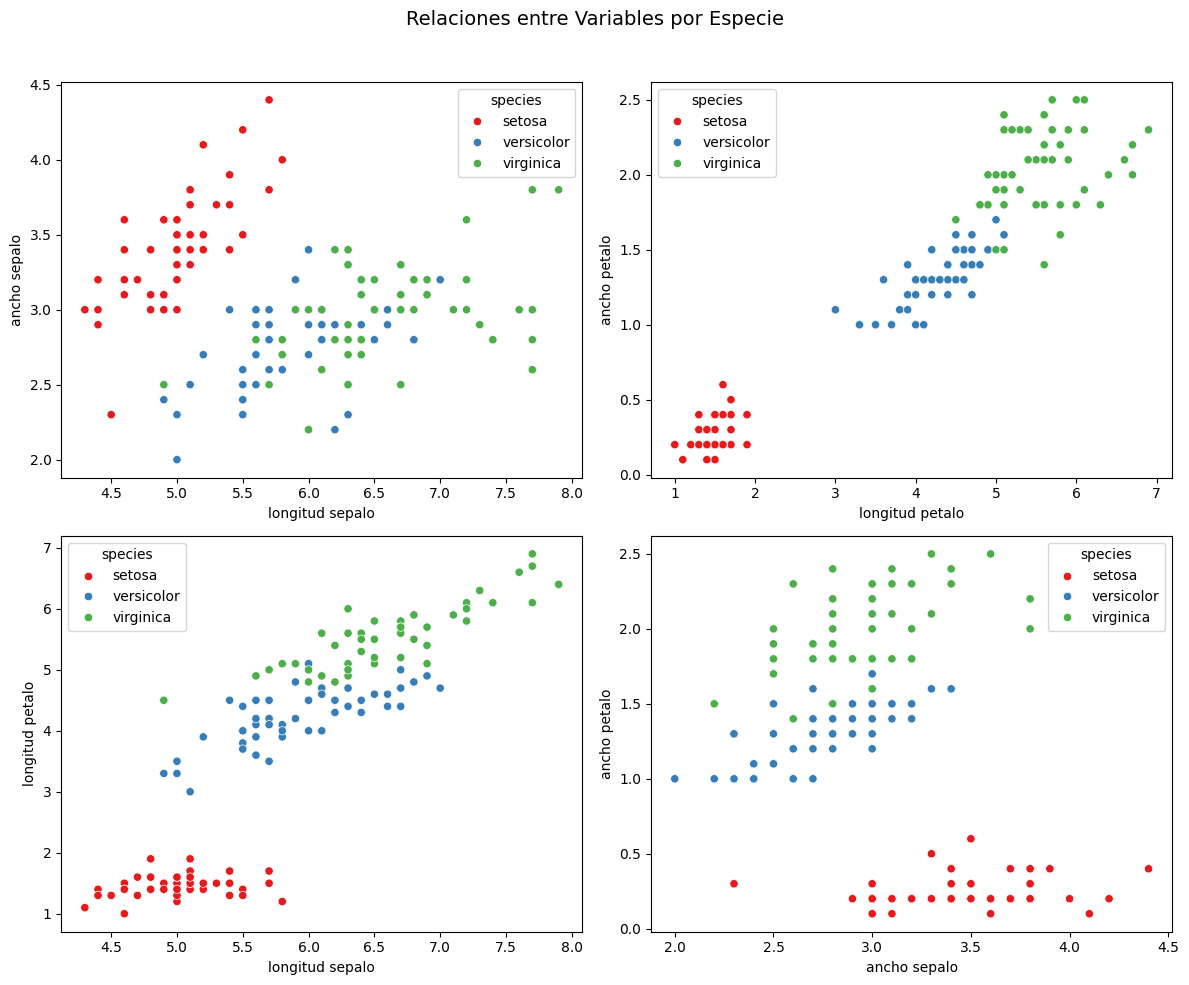

In [5]:
pairs = [
    ('longitud_sepalo', 'ancho_sepalo'),
    ('longitud_petalo', 'ancho_petalo'),
    ('longitud_sepalo', 'longitud_petalo'),
    ('ancho_sepalo',    'ancho_petalo')
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Relaciones entre Variables por Especie', fontsize=14)

for (x, y), ax in zip(pairs, axes.flatten()):
    sns.scatterplot(data=iris_df, x=x, y=y, hue='species', ax=ax, palette='Set1')
    ax.set_xlabel(x.replace('_', ' '))
    ax.set_ylabel(y.replace('_', ' '))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

- **Pétalo (longitud vs ancho)**: combinación más separable. *Setosa* completamente aislada.
- **Sépalo (longitud vs ancho)**: mayor solapamiento, menos útil para clasificación.
- *Versicolor* y *virginica* siempre presentan cierta superposición.

### 2.5 Boxplots

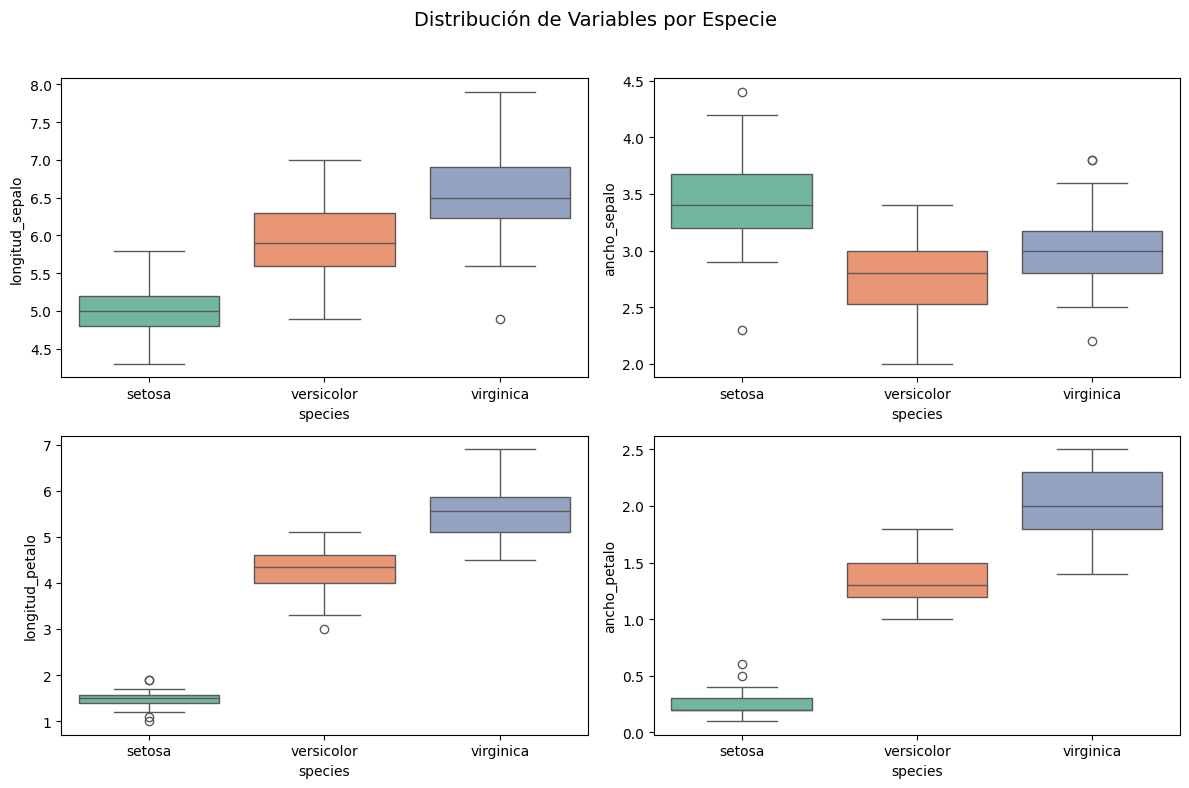

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribución de Variables por Especie', fontsize=14)

sns.boxplot(data=iris_df, x='species', y='longitud_sepalo', ax=axes[0, 0], palette='Set2')
sns.boxplot(data=iris_df, x='species', y='ancho_sepalo',    ax=axes[0, 1], palette='Set2')
sns.boxplot(data=iris_df, x='species', y='longitud_petalo', ax=axes[1, 0], palette='Set2')
sns.boxplot(data=iris_df, x='species', y='ancho_petalo',    ax=axes[1, 1], palette='Set2')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

*Setosa* tiene rangos bien separados en las variables del pétalo. Se observan algunos outliers en *virginica* para las variables del sépalo.

### 2.6 Matriz de Correlación Global

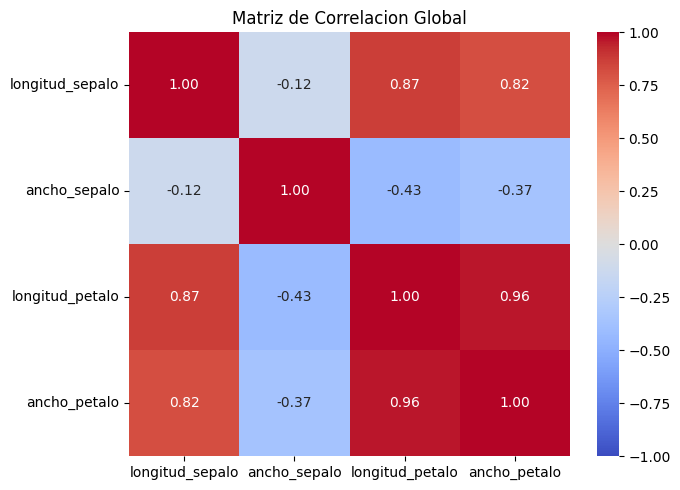

In [7]:
plt.figure(figsize=(7, 5))
sns.heatmap(iris_df[features].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de Correlacion Global')
plt.tight_layout()
plt.show()

### 2.7 Matrices de Correlación por Especie

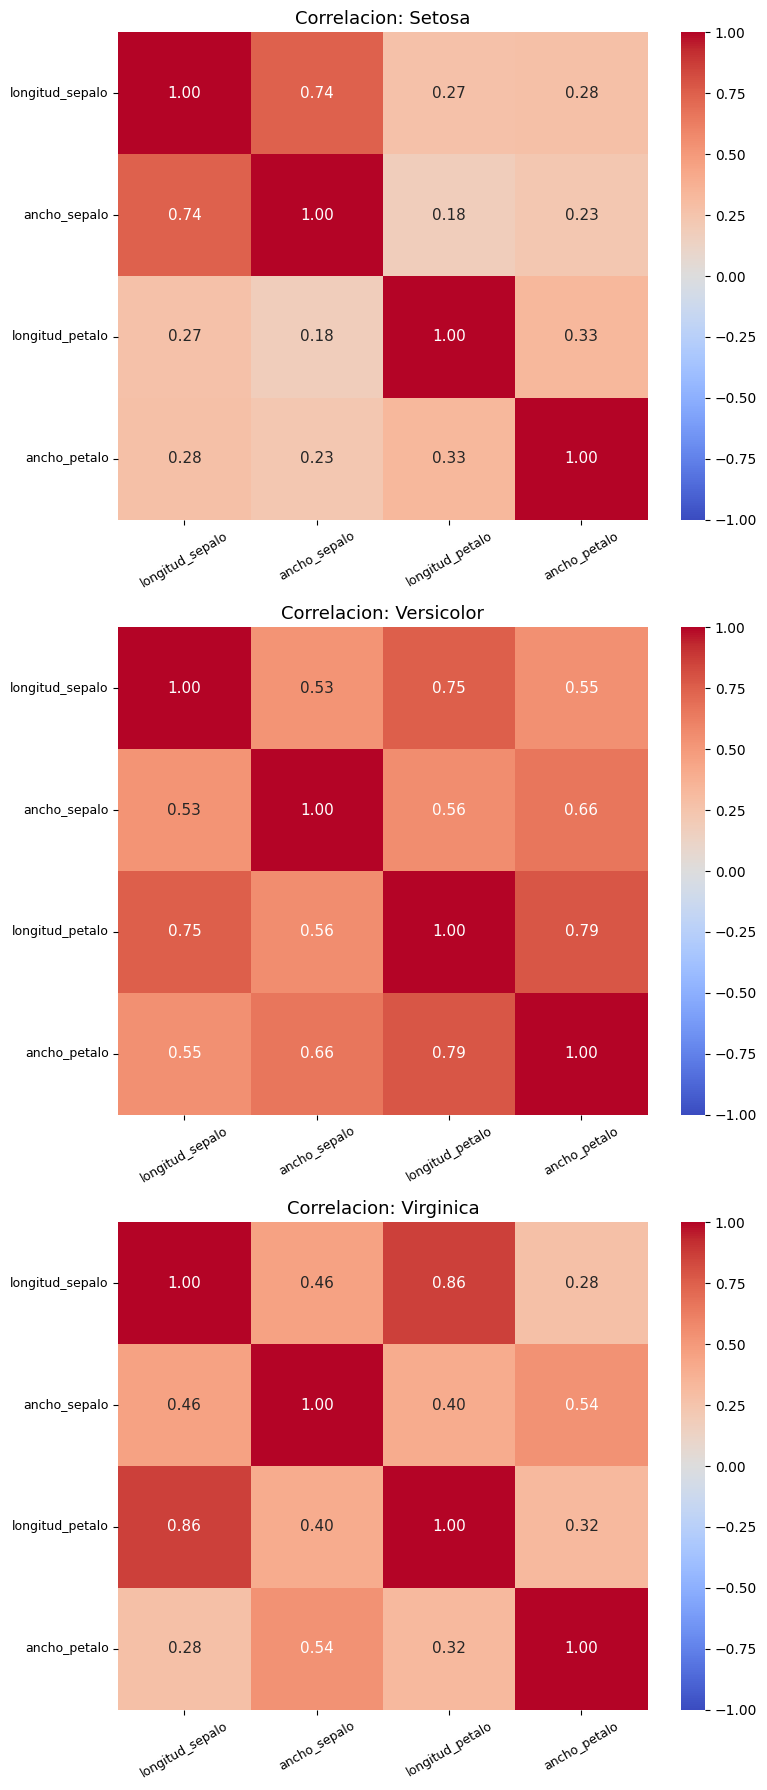

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(8, 18))

for ax, sp in zip(axes, ['setosa', 'versicolor', 'virginica']):
    datos_especie = iris_df[iris_df['species'] == sp][features]
    corr = datos_especie.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1,
                ax=ax, annot_kws={'size': 11})
    ax.set_title(f'Correlacion: {sp.capitalize()}', fontsize=13)
    ax.tick_params(axis='x', labelsize=9, rotation=30)
    ax.tick_params(axis='y', labelsize=9, rotation=0)

plt.tight_layout()
plt.show()

Las correlaciones varían según la especie. Esto indica que las relaciones entre variables no son uniformes en todo el dataset, lo que justifica crear nuevas features que capturen estas diferencias.

---
## 3. Análisis de Componentes Principales (PCA)

Aplicamos PCA para:
1. **Visualizar** el dataset en 2D y confirmar separabilidad.
2. **Analizar** cuánta información captura cada componente.
3. **Usar las componentes** como features alternativas para algunos modelos.

### 3.1 Varianza explicada por cada componente

Varianza explicada por componente:
  PC1: 0.730 individual | 0.730 acumulada
  PC2: 0.229 individual | 0.958 acumulada
  PC3: 0.037 individual | 0.995 acumulada
  PC4: 0.005 individual | 1.000 acumulada


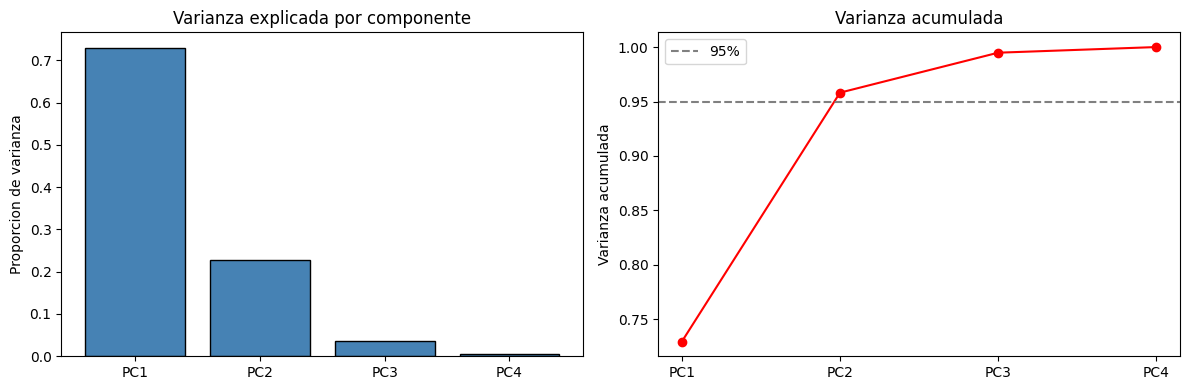

In [9]:
# Primero escalamos los datos (PCA es sensible a la escala)
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(iris_df[features])

# Calculamos PCA con todas las componentes
pca_full = PCA()
pca_full.fit(X_scaled)

varianza = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza)

print('Varianza explicada por componente:')
for i, (v, va) in enumerate(zip(varianza, varianza_acumulada)):
    print(f'  PC{i+1}: {v:.3f} individual | {va:.3f} acumulada')

# Grafico
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['PC1', 'PC2', 'PC3', 'PC4'], varianza, color='steelblue', edgecolor='black')
axes[0].set_title('Varianza explicada por componente')
axes[0].set_ylabel('Proporcion de varianza')

axes[1].plot(['PC1', 'PC2', 'PC3', 'PC4'], varianza_acumulada, 'ro-')
axes[1].axhline(y=0.95, color='gray', linestyle='--', label='95%')
axes[1].set_title('Varianza acumulada')
axes[1].set_ylabel('Varianza acumulada')
axes[1].legend()

plt.tight_layout()
plt.show()

Con **2 componentes principales** se explica más del **95% de la varianza** total. Esto significa que casi toda la información del dataset puede resumirse en 2 dimensiones.

### 3.2 Visualización 2D

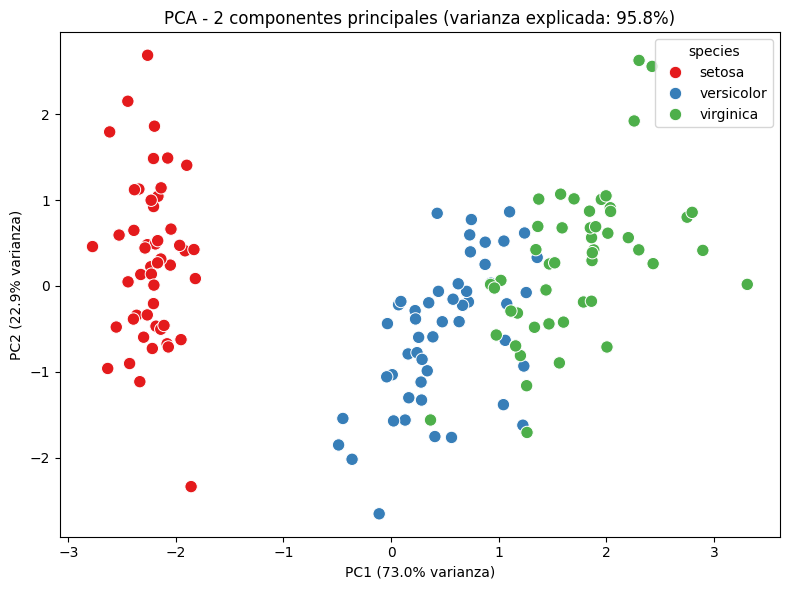

In [10]:
# Aplicamos PCA con 2 componentes
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

# Creamos un DataFrame para graficar
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['species'] = iris_df['species'].values

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='species', palette='Set1', s=80)
plt.title(f'PCA - 2 componentes principales (varianza explicada: {pca_2d.explained_variance_ratio_.sum():.1%})')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} varianza)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} varianza)')
plt.tight_layout()
plt.show()

La proyección en 2D confirma la separabilidad: *setosa* está perfectamente separada, mientras que *versicolor* y *virginica* presentan cierto solapamiento en la región intermedia.

---
## 4. Feature Engineering

Creamos nuevas variables a partir de las 4 originales:

| Tipo | Variables creadas |
|------|------------------|
| Ratios | `ratio_petalo`, `ratio_sepalo` |
| Binarias | `es_petalo_pequeno`, `es_ancho_petalo_pequeno` |
| Áreas | `area_petalo`, `area_sepalo` |
| Polinómicas | `longitud_petalo_2`, `ancho_petalo_2` |
| Combinaciones lineales | `diff_petalo`, `diff_sepalo`, `suma_petalo` |

In [11]:
# Ratios entre dimensiones
iris_df['ratio_petalo'] = iris_df['longitud_petalo'] / iris_df['ancho_petalo']
iris_df['ratio_sepalo'] = iris_df['longitud_sepalo'] / iris_df['ancho_sepalo']

# Binarias: umbrales que identifican directamente a setosa
iris_df['es_petalo_pequeno']       = (iris_df['longitud_petalo'] < 2.0).astype(int)
iris_df['es_ancho_petalo_pequeno'] = (iris_df['ancho_petalo']    < 0.6).astype(int)

# Areas: interaccion entre longitud y ancho
iris_df['area_petalo'] = iris_df['longitud_petalo'] * iris_df['ancho_petalo']
iris_df['area_sepalo'] = iris_df['longitud_sepalo'] * iris_df['ancho_sepalo']

# Polinomicas: capturan relaciones no lineales
iris_df['longitud_petalo_2'] = iris_df['longitud_petalo'] ** 2
iris_df['ancho_petalo_2']    = iris_df['ancho_petalo']    ** 2

# Combinaciones lineales
iris_df['diff_petalo'] = iris_df['longitud_petalo'] - iris_df['ancho_petalo']
iris_df['diff_sepalo'] = iris_df['longitud_sepalo'] - iris_df['ancho_sepalo']
iris_df['suma_petalo'] = iris_df['longitud_petalo'] + iris_df['ancho_petalo']

all_features = [c for c in iris_df.columns if c not in ['target', 'species']]
print(f'Total de features: {len(all_features)}')
print(all_features)

display(iris_df[all_features].head())

Total de features: 15
['longitud_sepalo', 'ancho_sepalo', 'longitud_petalo', 'ancho_petalo', 'ratio_petalo', 'ratio_sepalo', 'es_petalo_pequeno', 'es_ancho_petalo_pequeno', 'area_petalo', 'area_sepalo', 'longitud_petalo_2', 'ancho_petalo_2', 'diff_petalo', 'diff_sepalo', 'suma_petalo']


,longitud_sepalo,ancho_sepalo,longitud_petalo,ancho_petalo,ratio_petalo,ratio_sepalo,es_petalo_pequeno,es_ancho_petalo_pequeno,area_petalo,area_sepalo,longitud_petalo_2,ancho_petalo_2,diff_petalo,diff_sepalo,suma_petalo
0,5.1,3.5,1.4,0.2,7.0,1.457143,1,1,0.28,17.85,1.96,0.04,1.2,1.6,1.6
1,4.9,3.0,1.4,0.2,7.0,1.633333,1,1,0.28,14.70,1.96,0.04,1.2,1.9,1.6
2,4.7,3.2,1.3,0.2,6.5,1.468750,1,1,0.26,15.04,1.69,0.04,1.1,1.5,1.5
3,4.6,3.1,1.5,0.2,7.5,1.483871,1,1,0.30,14.26,2.25,0.04,1.3,1.5,1.7
4,5.0,3.6,1.4,0.2,7.0,1.388889,1,1,0.28,18.00,1.96,0.04,1.2,1.4,1.6


Se generaron **15 features** en total. Las features binarias actúan como reglas directas para identificar *setosa*. Las polinómicas capturan relaciones no lineales y las áreas combinan dimensiones con sentido geométrico.

---
## 5. Preparación para el Modelado

In [12]:
# Variable objetivo
y = iris_df['target']

# Definimos distintos conjuntos de features para los experimentos
features_originales = ['longitud_sepalo', 'ancho_sepalo', 'longitud_petalo', 'ancho_petalo']
features_petalo     = ['longitud_petalo', 'ancho_petalo', 'ratio_petalo', 'area_petalo']
features_binarias   = ['es_petalo_pequeno', 'es_ancho_petalo_pequeno']
features_orig_ratio = ['longitud_sepalo', 'ancho_sepalo', 'longitud_petalo', 'ancho_petalo',
                        'ratio_petalo', 'ratio_sepalo']
features_todas      = [c for c in iris_df.columns if c not in ['target', 'species']]

# Split estratificado para todos los experimentos
# stratify=y garantiza la misma proporcion de clases en train y test
X_tr_orig,   X_te_orig,   y_train, y_test = train_test_split(
    iris_df[features_originales], y, test_size=0.2, random_state=42, stratify=y
)
X_tr_pet,    X_te_pet,    _, _ = train_test_split(
    iris_df[features_petalo], y, test_size=0.2, random_state=42, stratify=y
)
X_tr_bin,    X_te_bin,    _, _ = train_test_split(
    iris_df[features_binarias], y, test_size=0.2, random_state=42, stratify=y
)
X_tr_ratio,  X_te_ratio,  _, _ = train_test_split(
    iris_df[features_orig_ratio], y, test_size=0.2, random_state=42, stratify=y
)
X_tr_todas,  X_te_todas,  _, _ = train_test_split(
    iris_df[features_todas], y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_tr_orig.shape[0]} muestras | Test: {X_te_orig.shape[0]} muestras')
print(f'Distribucion train: {dict(y_train.value_counts().sort_index())}')
print(f'Distribucion test:  {dict(y_test.value_counts().sort_index())}')

Train: 120 muestras | Test: 30 muestras
Distribucion train: {0: 40, 1: 40, 2: 40}
Distribucion test:  {0: 10, 1: 10, 2: 10}


Se usan el mismo `random_state=42` y `stratify=y` en todos los splits para que las comparaciones entre modelos sean justas (mismo conjunto de test para todos).

### ¿Qué métrica priorizar?

Para este problema de clasificación de flores, **el dataset es balanceado y no hay un costo asimétrico** entre los errores (clasificar mal una especie no tiene consecuencias más graves que clasificar mal otra). Por eso:

- Usamos **Accuracy** como métrica principal (válida con clases balanceadas).
- Complementamos con **F1-macro**, que promedia el F1 de cada clase por igual — útil para verificar que el modelo no ignora ninguna especie.
- Prestamos atención especial a los errores en *versicolor* y *virginica*, que son las clases con mayor solapamiento.

Si fuera un caso médico (ej: diagnóstico), priorizaríamos **recall** (minimizar Falsos Negativos). En este caso biológico/académico, F1-macro es suficiente.

---
## 6. Experimentos de Modelado

Para cada modelo registramos: accuracy, F1-macro, tiempo de entrenamiento/predicción, errores Tipo I (Falsos Positivos) y Tipo II (Falsos Negativos).

### 6.1 Random Forest — Baseline (4 features originales)

Accuracy : 0.9000
F1-macro : 0.8997
T. entrenamiento: 51.2ms | T. prediccion: 1.98ms

Reporte de Clasificacion:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



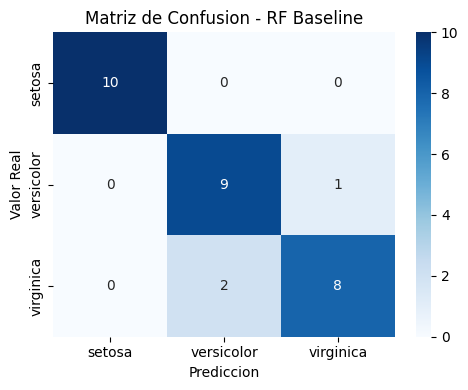

Errores por clase:
  setosa: FP (Tipo I) = 0 | FN (Tipo II) = 0
  versicolor: FP (Tipo I) = 2 | FN (Tipo II) = 1
  virginica: FP (Tipo I) = 1 | FN (Tipo II) = 2


In [13]:
# Entrenamiento
inicio = time.time()
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_tr_orig, y_train)
t_train = time.time() - inicio

# Prediccion
inicio = time.time()
y_pred_rf_base = rf_base.predict(X_te_orig)
t_pred = time.time() - inicio

acc = accuracy_score(y_test, y_pred_rf_base)
f1  = f1_score(y_test, y_pred_rf_base, average='macro')

print(f'Accuracy : {acc:.4f}')
print(f'F1-macro : {f1:.4f}')
print(f'T. entrenamiento: {t_train*1000:.1f}ms | T. prediccion: {t_pred*1000:.2f}ms')
print('\nReporte de Clasificacion:')
print(classification_report(y_test, y_pred_rf_base, target_names=CLASS_NAMES))

# Matriz de confusion
cm = confusion_matrix(y_test, y_pred_rf_base)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Matriz de Confusion - RF Baseline')
plt.xlabel('Prediccion')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

# Errores Tipo I y Tipo II por clase
print('Errores por clase:')
for i, clase in enumerate(CLASS_NAMES):
    fp = cm.sum(axis=0)[i] - cm[i][i]  # Falsos Positivos (Error Tipo I)
    fn = cm.sum(axis=1)[i] - cm[i][i]  # Falsos Negativos (Error Tipo II)
    print(f'  {clase}: FP (Tipo I) = {fp} | FN (Tipo II) = {fn}')

resultados.append({'Modelo': 'RF Baseline', 'Features': 'originales (4)',
    'Nro. Features': 4, 'Accuracy': round(acc, 4), 'F1-macro': round(f1, 4),
    'T. train (ms)': round(t_train*1000, 1), 'T. pred (ms)': round(t_pred*1000, 3),
    'Interpretabilidad': 'Media'})

### 6.2 Random Forest — Todas las features

Accuracy : 0.9667
F1-macro : 0.9666
T. entrenamiento: 52.3ms | T. prediccion: 2.63ms

Reporte de Clasificacion:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



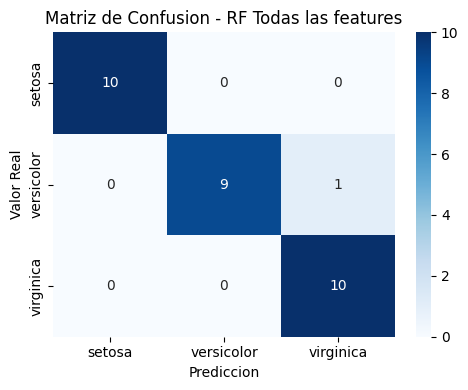

  setosa: FP (Tipo I) = 0 | FN (Tipo II) = 0
  versicolor: FP (Tipo I) = 0 | FN (Tipo II) = 1
  virginica: FP (Tipo I) = 1 | FN (Tipo II) = 0


In [14]:
inicio = time.time()
rf_todas = RandomForestClassifier(n_estimators=100, random_state=42)
rf_todas.fit(X_tr_todas, y_train)
t_train = time.time() - inicio

inicio = time.time()
y_pred_rf_todas = rf_todas.predict(X_te_todas)
t_pred = time.time() - inicio

acc = accuracy_score(y_test, y_pred_rf_todas)
f1  = f1_score(y_test, y_pred_rf_todas, average='macro')

print(f'Accuracy : {acc:.4f}')
print(f'F1-macro : {f1:.4f}')
print(f'T. entrenamiento: {t_train*1000:.1f}ms | T. prediccion: {t_pred*1000:.2f}ms')
print('\nReporte de Clasificacion:')
print(classification_report(y_test, y_pred_rf_todas, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred_rf_todas)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Matriz de Confusion - RF Todas las features')
plt.xlabel('Prediccion')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

for i, clase in enumerate(CLASS_NAMES):
    fp = cm.sum(axis=0)[i] - cm[i][i]
    fn = cm.sum(axis=1)[i] - cm[i][i]
    print(f'  {clase}: FP (Tipo I) = {fp} | FN (Tipo II) = {fn}')

resultados.append({'Modelo': 'RF Todas features', 'Features': 'todas (15)',
    'Nro. Features': 15, 'Accuracy': round(acc, 4), 'F1-macro': round(f1, 4),
    'T. train (ms)': round(t_train*1000, 1), 'T. pred (ms)': round(t_pred*1000, 3),
    'Interpretabilidad': 'Media'})

#### Importancia de features — RF Todas

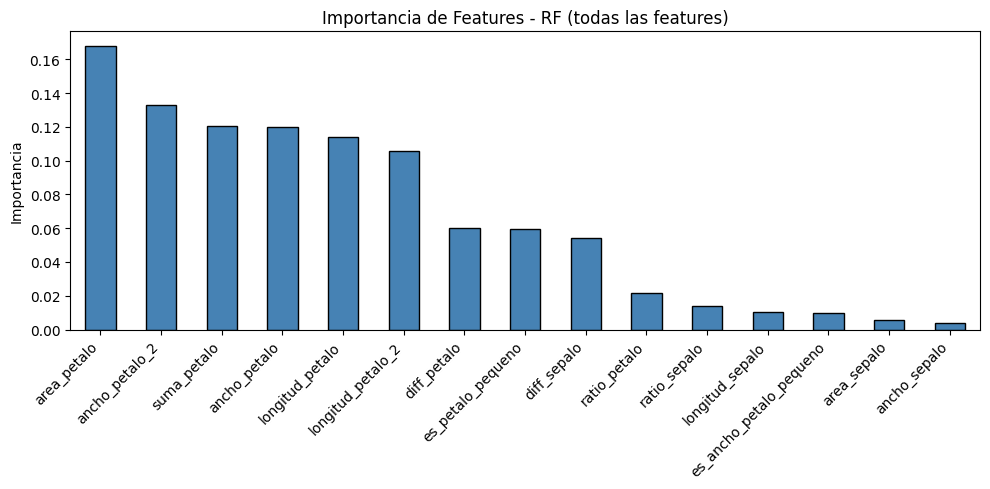

Top 5 features:
area_petalo        0.168139
ancho_petalo_2     0.132854
suma_petalo        0.120694
ancho_petalo       0.120015
longitud_petalo    0.114211
dtype: float64


In [15]:
importancias = pd.Series(rf_todas.feature_importances_, index=features_todas)
importancias = importancias.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importancias.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Importancia de Features - RF (todas las features)')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 5 features:')
print(importancias.head())

Las features del pétalo dominan en importancia, lo que confirma lo observado en el EDA. Usaremos esta información para el experimento de selección de features en la sección 6.8.

### 6.3 Random Forest — Solo features del pétalo

Accuracy : 0.9667
F1-macro : 0.9666
T. entrenamiento: 49.8ms | T. prediccion: 1.95ms

Reporte de Clasificacion:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



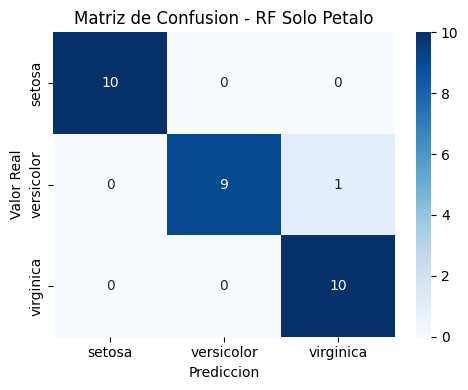

  setosa: FP (Tipo I) = 0 | FN (Tipo II) = 0
  versicolor: FP (Tipo I) = 0 | FN (Tipo II) = 1
  virginica: FP (Tipo I) = 1 | FN (Tipo II) = 0


In [16]:
inicio = time.time()
rf_pet = RandomForestClassifier(n_estimators=100, random_state=42)
rf_pet.fit(X_tr_pet, y_train)
t_train = time.time() - inicio

inicio = time.time()
y_pred_rf_pet = rf_pet.predict(X_te_pet)
t_pred = time.time() - inicio

acc = accuracy_score(y_test, y_pred_rf_pet)
f1  = f1_score(y_test, y_pred_rf_pet, average='macro')

print(f'Accuracy : {acc:.4f}')
print(f'F1-macro : {f1:.4f}')
print(f'T. entrenamiento: {t_train*1000:.1f}ms | T. prediccion: {t_pred*1000:.2f}ms')
print('\nReporte de Clasificacion:')
print(classification_report(y_test, y_pred_rf_pet, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred_rf_pet)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Matriz de Confusion - RF Solo Petalo')
plt.xlabel('Prediccion')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

for i, clase in enumerate(CLASS_NAMES):
    fp = cm.sum(axis=0)[i] - cm[i][i]
    fn = cm.sum(axis=1)[i] - cm[i][i]
    print(f'  {clase}: FP (Tipo I) = {fp} | FN (Tipo II) = {fn}')

resultados.append({'Modelo': 'RF Solo petalo', 'Features': 'petalo (4)',
    'Nro. Features': 4, 'Accuracy': round(acc, 4), 'F1-macro': round(f1, 4),
    'T. train (ms)': round(t_train*1000, 1), 'T. pred (ms)': round(t_pred*1000, 3),
    'Interpretabilidad': 'Media'})

### 6.4 Random Forest — Solo características binarias del pétalo

Probamos con solo las dos variables binarias que creamos para identificar *setosa*. Esto nos permite ver si esas reglas simples son suficientes para clasificar bien.

Accuracy : 0.6667
F1-macro : 0.5556
T. entrenamiento: 97.8ms | T. prediccion: 2.89ms

Reporte de Clasificacion:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.00      0.00      0.00        10
   virginica       0.50      1.00      0.67        10

    accuracy                           0.67        30
   macro avg       0.50      0.67      0.56        30
weighted avg       0.50      0.67      0.56        30



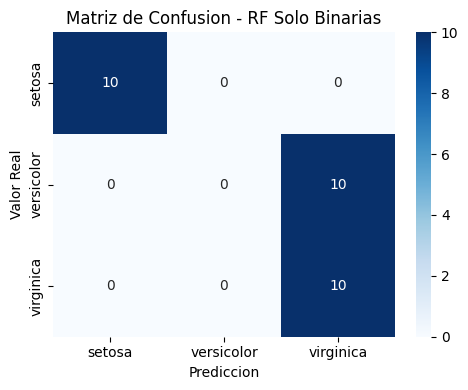

  setosa: FP (Tipo I) = 0 | FN (Tipo II) = 0
  versicolor: FP (Tipo I) = 0 | FN (Tipo II) = 10
  virginica: FP (Tipo I) = 10 | FN (Tipo II) = 0


In [17]:
inicio = time.time()
rf_bin = RandomForestClassifier(n_estimators=100, random_state=42)
rf_bin.fit(X_tr_bin, y_train)
t_train = time.time() - inicio

inicio = time.time()
y_pred_rf_bin = rf_bin.predict(X_te_bin)
t_pred = time.time() - inicio

acc = accuracy_score(y_test, y_pred_rf_bin)
f1  = f1_score(y_test, y_pred_rf_bin, average='macro')

print(f'Accuracy : {acc:.4f}')
print(f'F1-macro : {f1:.4f}')
print(f'T. entrenamiento: {t_train*1000:.1f}ms | T. prediccion: {t_pred*1000:.2f}ms')
print('\nReporte de Clasificacion:')
print(classification_report(y_test, y_pred_rf_bin, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred_rf_bin)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Matriz de Confusion - RF Solo Binarias')
plt.xlabel('Prediccion')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

for i, clase in enumerate(CLASS_NAMES):
    fp = cm.sum(axis=0)[i] - cm[i][i]
    fn = cm.sum(axis=1)[i] - cm[i][i]
    print(f'  {clase}: FP (Tipo I) = {fp} | FN (Tipo II) = {fn}')

resultados.append({'Modelo': 'RF Solo binarias', 'Features': 'binarias (2)',
    'Nro. Features': 2, 'Accuracy': round(acc, 4), 'F1-macro': round(f1, 4),
    'T. train (ms)': round(t_train*1000, 1), 'T. pred (ms)': round(t_pred*1000, 3),
    'Interpretabilidad': 'Alta'})

### 6.5 Random Forest — Originales + Ratios

Accuracy : 0.9333
F1-macro : 0.9333
T. entrenamiento: 49.0ms | T. prediccion: 1.95ms

Reporte de Clasificacion:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



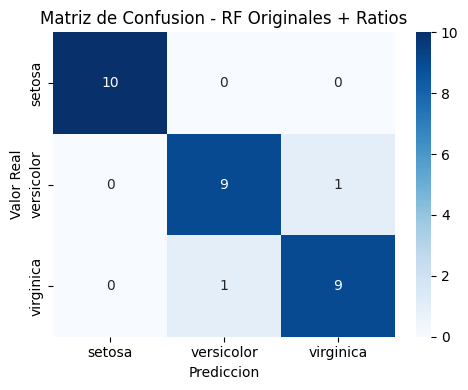

  setosa: FP (Tipo I) = 0 | FN (Tipo II) = 0
  versicolor: FP (Tipo I) = 1 | FN (Tipo II) = 1
  virginica: FP (Tipo I) = 1 | FN (Tipo II) = 1


In [18]:
inicio = time.time()
rf_ratio = RandomForestClassifier(n_estimators=100, random_state=42)
rf_ratio.fit(X_tr_ratio, y_train)
t_train = time.time() - inicio

inicio = time.time()
y_pred_rf_ratio = rf_ratio.predict(X_te_ratio)
t_pred = time.time() - inicio

acc = accuracy_score(y_test, y_pred_rf_ratio)
f1  = f1_score(y_test, y_pred_rf_ratio, average='macro')

print(f'Accuracy : {acc:.4f}')
print(f'F1-macro : {f1:.4f}')
print(f'T. entrenamiento: {t_train*1000:.1f}ms | T. prediccion: {t_pred*1000:.2f}ms')
print('\nReporte de Clasificacion:')
print(classification_report(y_test, y_pred_rf_ratio, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred_rf_ratio)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Matriz de Confusion - RF Originales + Ratios')
plt.xlabel('Prediccion')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

for i, clase in enumerate(CLASS_NAMES):
    fp = cm.sum(axis=0)[i] - cm[i][i]
    fn = cm.sum(axis=1)[i] - cm[i][i]
    print(f'  {clase}: FP (Tipo I) = {fp} | FN (Tipo II) = {fn}')

resultados.append({'Modelo': 'RF Orig + Ratios', 'Features': 'originales + ratios (6)',
    'Nro. Features': 6, 'Accuracy': round(acc, 4), 'F1-macro': round(f1, 4),
    'T. train (ms)': round(t_train*1000, 1), 'T. pred (ms)': round(t_pred*1000, 3),
    'Interpretabilidad': 'Media'})

### 6.6 KNN — Pipeline (StandardScaler + KNN)

KNN es sensible a la escala de las variables. Usamos un **Pipeline de sklearn** que aplica `StandardScaler` antes del modelo, garantizando que el escalado se aprende solo sobre los datos de entrenamiento (sin data leakage). Primero buscamos el mejor valor de `k` con validación cruzada.

k=1: accuracy CV = 0.9417
k=3: accuracy CV = 0.9583
k=5: accuracy CV = 0.9667
k=7: accuracy CV = 0.9583
k=9: accuracy CV = 0.9583
k=11: accuracy CV = 0.9583

Mejor k: 5  (accuracy CV: 0.9667)


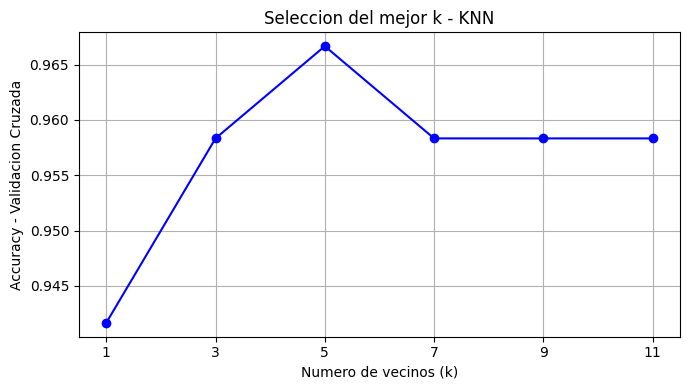

In [19]:
# Buscamos el mejor k con validacion cruzada
k_values  = [1, 3, 5, 7, 9, 11]
cv_scores = []

for k in k_values:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('knn',    KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe_k, X_tr_orig, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())
    print(f'k={k}: accuracy CV = {scores.mean():.4f}')

best_k = k_values[np.argmax(cv_scores)]
print(f'\nMejor k: {best_k}  (accuracy CV: {max(cv_scores):.4f})')

plt.figure(figsize=(7, 4))
plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='b')
plt.xlabel('Numero de vecinos (k)')
plt.ylabel('Accuracy - Validacion Cruzada')
plt.title('Seleccion del mejor k - KNN')
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()

Accuracy : 0.9333
F1-macro : 0.9327
T. entrenamiento: 1.6ms | T. prediccion: 2.67ms

Reporte de Clasificacion:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



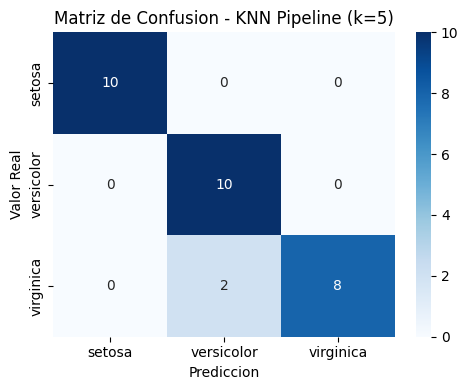

  setosa: FP (Tipo I) = 0 | FN (Tipo II) = 0
  versicolor: FP (Tipo I) = 2 | FN (Tipo II) = 0
  virginica: FP (Tipo I) = 0 | FN (Tipo II) = 2


In [20]:
# Entrenamos KNN con el mejor k usando Pipeline
inicio = time.time()
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsClassifier(n_neighbors=best_k))
])
pipe_knn.fit(X_tr_orig, y_train)
t_train = time.time() - inicio

inicio = time.time()
y_pred_knn = pipe_knn.predict(X_te_orig)
t_pred = time.time() - inicio

acc = accuracy_score(y_test, y_pred_knn)
f1  = f1_score(y_test, y_pred_knn, average='macro')

print(f'Accuracy : {acc:.4f}')
print(f'F1-macro : {f1:.4f}')
print(f'T. entrenamiento: {t_train*1000:.1f}ms | T. prediccion: {t_pred*1000:.2f}ms')
print('\nReporte de Clasificacion:')
print(classification_report(y_test, y_pred_knn, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Matriz de Confusion - KNN Pipeline (k={best_k})')
plt.xlabel('Prediccion')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

for i, clase in enumerate(CLASS_NAMES):
    fp = cm.sum(axis=0)[i] - cm[i][i]
    fn = cm.sum(axis=1)[i] - cm[i][i]
    print(f'  {clase}: FP (Tipo I) = {fp} | FN (Tipo II) = {fn}')

resultados.append({'Modelo': f'KNN Pipeline (k={best_k})', 'Features': 'originales (4)',
    'Nro. Features': 4, 'Accuracy': round(acc, 4), 'F1-macro': round(f1, 4),
    'T. train (ms)': round(t_train*1000, 1), 'T. pred (ms)': round(t_pred*1000, 3),
    'Interpretabilidad': 'Alta'})

### 6.7 Gradient Boosting

Accuracy : 0.9667
F1-macro : 0.9666
T. entrenamiento: 124.5ms | T. prediccion: 1.81ms

Reporte de Clasificacion:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



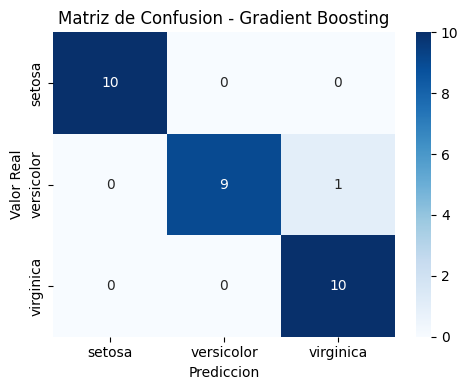

  setosa: FP (Tipo I) = 0 | FN (Tipo II) = 0
  versicolor: FP (Tipo I) = 0 | FN (Tipo II) = 1
  virginica: FP (Tipo I) = 1 | FN (Tipo II) = 0


In [21]:
inicio = time.time()
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_tr_todas, y_train)
t_train = time.time() - inicio

inicio = time.time()
y_pred_gb = gb.predict(X_te_todas)
t_pred = time.time() - inicio

acc = accuracy_score(y_test, y_pred_gb)
f1  = f1_score(y_test, y_pred_gb, average='macro')

print(f'Accuracy : {acc:.4f}')
print(f'F1-macro : {f1:.4f}')
print(f'T. entrenamiento: {t_train*1000:.1f}ms | T. prediccion: {t_pred*1000:.2f}ms')
print('\nReporte de Clasificacion:')
print(classification_report(y_test, y_pred_gb, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Matriz de Confusion - Gradient Boosting')
plt.xlabel('Prediccion')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

for i, clase in enumerate(CLASS_NAMES):
    fp = cm.sum(axis=0)[i] - cm[i][i]
    fn = cm.sum(axis=1)[i] - cm[i][i]
    print(f'  {clase}: FP (Tipo I) = {fp} | FN (Tipo II) = {fn}')

resultados.append({'Modelo': 'Gradient Boosting', 'Features': 'todas (15)',
    'Nro. Features': 15, 'Accuracy': round(acc, 4), 'F1-macro': round(f1, 4),
    'T. train (ms)': round(t_train*1000, 1), 'T. pred (ms)': round(t_pred*1000, 3),
    'Interpretabilidad': 'Baja'})

### 6.8 AdaBoost

Accuracy : 0.9333
F1-macro : 0.9333
T. entrenamiento: 56.7ms | T. prediccion: 3.94ms

Reporte de Clasificacion:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



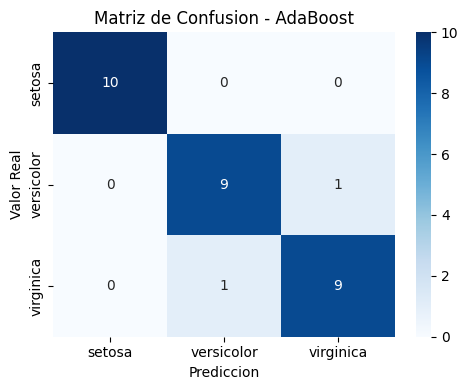

  setosa: FP (Tipo I) = 0 | FN (Tipo II) = 0
  versicolor: FP (Tipo I) = 1 | FN (Tipo II) = 1
  virginica: FP (Tipo I) = 1 | FN (Tipo II) = 1


In [22]:
inicio = time.time()
ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42, algorithm='SAMME')
ada.fit(X_tr_todas, y_train)
t_train = time.time() - inicio

inicio = time.time()
y_pred_ada = ada.predict(X_te_todas)
t_pred = time.time() - inicio

acc = accuracy_score(y_test, y_pred_ada)
f1  = f1_score(y_test, y_pred_ada, average='macro')

print(f'Accuracy : {acc:.4f}')
print(f'F1-macro : {f1:.4f}')
print(f'T. entrenamiento: {t_train*1000:.1f}ms | T. prediccion: {t_pred*1000:.2f}ms')
print('\nReporte de Clasificacion:')
print(classification_report(y_test, y_pred_ada, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred_ada)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Matriz de Confusion - AdaBoost')
plt.xlabel('Prediccion')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

for i, clase in enumerate(CLASS_NAMES):
    fp = cm.sum(axis=0)[i] - cm[i][i]
    fn = cm.sum(axis=1)[i] - cm[i][i]
    print(f'  {clase}: FP (Tipo I) = {fp} | FN (Tipo II) = {fn}')

resultados.append({'Modelo': 'AdaBoost', 'Features': 'todas (15)',
    'Nro. Features': 15, 'Accuracy': round(acc, 4), 'F1-macro': round(f1, 4),
    'T. train (ms)': round(t_train*1000, 1), 'T. pred (ms)': round(t_pred*1000, 3),
    'Interpretabilidad': 'Baja'})

### 6.9 XGBoost

Accuracy : 0.9333
F1-macro : 0.9333
T. entrenamiento: 76.6ms | T. prediccion: 1.63ms

Reporte de Clasificacion:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



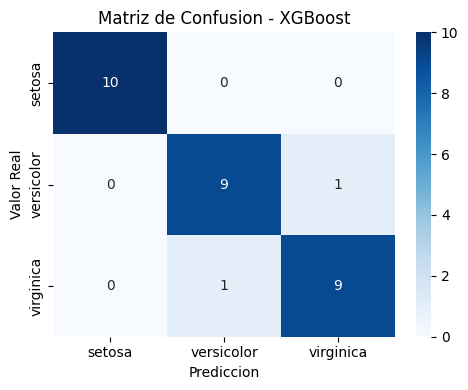

  setosa: FP (Tipo I) = 0 | FN (Tipo II) = 0
  versicolor: FP (Tipo I) = 1 | FN (Tipo II) = 1
  virginica: FP (Tipo I) = 1 | FN (Tipo II) = 1


In [23]:
if XGBOOST_AVAILABLE:
    inicio = time.time()
    xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,
                        random_state=42, eval_metric='mlogloss', verbosity=0)
    xgb.fit(X_tr_todas, y_train)
    t_train = time.time() - inicio

    inicio = time.time()
    y_pred_xgb = xgb.predict(X_te_todas)
    t_pred = time.time() - inicio

    acc = accuracy_score(y_test, y_pred_xgb)
    f1  = f1_score(y_test, y_pred_xgb, average='macro')

    print(f'Accuracy : {acc:.4f}')
    print(f'F1-macro : {f1:.4f}')
    print(f'T. entrenamiento: {t_train*1000:.1f}ms | T. prediccion: {t_pred*1000:.2f}ms')
    print('\nReporte de Clasificacion:')
    print(classification_report(y_test, y_pred_xgb, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_test, y_pred_xgb)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Matriz de Confusion - XGBoost')
    plt.xlabel('Prediccion')
    plt.ylabel('Valor Real')
    plt.tight_layout()
    plt.show()

    for i, clase in enumerate(CLASS_NAMES):
        fp = cm.sum(axis=0)[i] - cm[i][i]
        fn = cm.sum(axis=1)[i] - cm[i][i]
        print(f'  {clase}: FP (Tipo I) = {fp} | FN (Tipo II) = {fn}')

    resultados.append({'Modelo': 'XGBoost', 'Features': 'todas (15)',
        'Nro. Features': 15, 'Accuracy': round(acc, 4), 'F1-macro': round(f1, 4),
        'T. train (ms)': round(t_train*1000, 1), 'T. pred (ms)': round(t_pred*1000, 3),
        'Interpretabilidad': 'Baja'})
else:
    print('XGBoost no disponible. Instalar con: pip install xgboost')

### 6.10 Pipeline RF → Gradient Boosting (tuneado)

Combinación de técnicas:
1. Usamos la **importancia de features del RF** para quedarnos con las más relevantes.
2. Con ese subconjunto, buscamos los mejores hiperparámetros para un Gradient Boosting con validación cruzada.
3. Entrenamos el modelo final con esos parámetros.

In [24]:
# Paso 1: seleccionamos features con importancia mayor al 5%
top_features = importancias[importancias > 0.05].index.tolist()
print(f'Features seleccionadas ({len(top_features)}):')
for f in top_features:
    print(f'  {f}: {importancias[f]:.3f}')

X_tr_top, X_te_top, _, _ = train_test_split(
    iris_df[top_features], y, test_size=0.2, random_state=42, stratify=y
)

Features seleccionadas (9):
  area_petalo: 0.168
  ancho_petalo_2: 0.133
  suma_petalo: 0.121
  ancho_petalo: 0.120
  longitud_petalo: 0.114
  longitud_petalo_2: 0.106
  diff_petalo: 0.060
  es_petalo_pequeno: 0.060
  diff_sepalo: 0.054


In [25]:
# Paso 2: buscamos los mejores hiperparametros con validacion cruzada
param_grid = [
    {'n_estimators': 50,  'learning_rate': 0.1,  'max_depth': 2},
    {'n_estimators': 100, 'learning_rate': 0.1,  'max_depth': 3},
    {'n_estimators': 150, 'learning_rate': 0.05, 'max_depth': 3},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 4},
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_f1    = 0
best_params = None

for params in param_grid:
    modelo_temp = GradientBoostingClassifier(**params, random_state=42)
    scores = cross_val_score(modelo_temp, X_tr_top, y_train, cv=cv, scoring='f1_macro')
    print(f'Params: {params} -> F1-macro CV: {scores.mean():.4f}')
    if scores.mean() > best_f1:
        best_f1     = scores.mean()
        best_params = params

print(f'\nMejores parametros: {best_params}')
print(f'Mejor F1-macro CV : {best_f1:.4f}')

Params: {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 2} -> F1-macro CV: 0.9482
Params: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3} -> F1-macro CV: 0.9482
Params: {'n_estimators': 150, 'learning_rate': 0.05, 'max_depth': 3} -> F1-macro CV: 0.9580
Params: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 4} -> F1-macro CV: 0.9496

Mejores parametros: {'n_estimators': 150, 'learning_rate': 0.05, 'max_depth': 3}
Mejor F1-macro CV : 0.9580


Accuracy : 0.9667
F1-macro : 0.9666
T. entrenamiento: 134.0ms | T. prediccion: 1.84ms

Reporte de Clasificacion:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



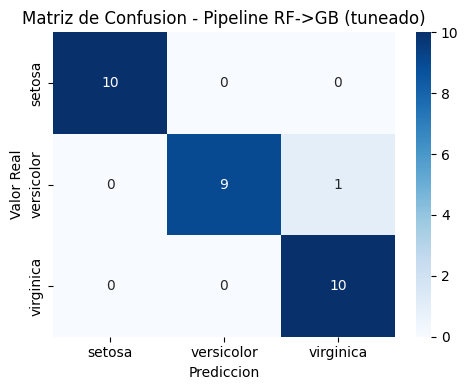

  setosa: FP (Tipo I) = 0 | FN (Tipo II) = 0
  versicolor: FP (Tipo I) = 0 | FN (Tipo II) = 1
  virginica: FP (Tipo I) = 1 | FN (Tipo II) = 0


In [26]:
# Paso 3: entrenamos el modelo final
inicio = time.time()
gb_tuned = GradientBoostingClassifier(**best_params, random_state=42)
gb_tuned.fit(X_tr_top, y_train)
t_train = time.time() - inicio

inicio = time.time()
y_pred_gb_tuned = gb_tuned.predict(X_te_top)
t_pred = time.time() - inicio

acc = accuracy_score(y_test, y_pred_gb_tuned)
f1  = f1_score(y_test, y_pred_gb_tuned, average='macro')

print(f'Accuracy : {acc:.4f}')
print(f'F1-macro : {f1:.4f}')
print(f'T. entrenamiento: {t_train*1000:.1f}ms | T. prediccion: {t_pred*1000:.2f}ms')
print('\nReporte de Clasificacion:')
print(classification_report(y_test, y_pred_gb_tuned, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred_gb_tuned)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Matriz de Confusion - Pipeline RF->GB (tuneado)')
plt.xlabel('Prediccion')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

for i, clase in enumerate(CLASS_NAMES):
    fp = cm.sum(axis=0)[i] - cm[i][i]
    fn = cm.sum(axis=1)[i] - cm[i][i]
    print(f'  {clase}: FP (Tipo I) = {fp} | FN (Tipo II) = {fn}')

resultados.append({'Modelo': 'Pipeline RF->GB (tuneado)', 'Features': f'top features ({len(top_features)})',
    'Nro. Features': len(top_features), 'Accuracy': round(acc, 4), 'F1-macro': round(f1, 4),
    'T. train (ms)': round(t_train*1000, 1), 'T. pred (ms)': round(t_pred*1000, 3),
    'Interpretabilidad': 'Baja'})

### 6.11 Pipeline: PCA → Gradient Boosting

Usamos las componentes principales como features. El Pipeline de sklearn encadena `StandardScaler → PCA → GradientBoosting`, aplicando cada transformación solo sobre los datos de entrenamiento.

Accuracy : 0.8667
F1-macro : 0.8667
T. entrenamiento: 156.1ms | T. prediccion: 1.14ms

Reporte de Clasificacion:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.80      0.80      0.80        10
   virginica       0.80      0.80      0.80        10

    accuracy                           0.87        30
   macro avg       0.87      0.87      0.87        30
weighted avg       0.87      0.87      0.87        30



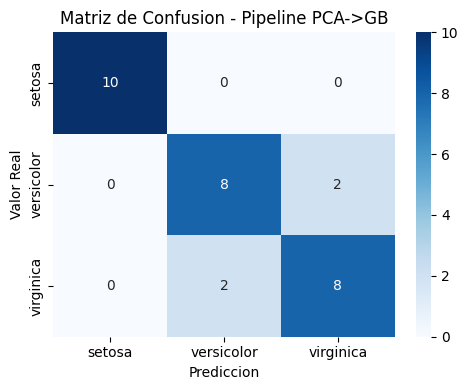

  setosa: FP (Tipo I) = 0 | FN (Tipo II) = 0
  versicolor: FP (Tipo I) = 2 | FN (Tipo II) = 2
  virginica: FP (Tipo I) = 2 | FN (Tipo II) = 2


In [27]:
inicio = time.time()
pipe_pca_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=2)),
    ('gb',     GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                          max_depth=3, random_state=42))
])
pipe_pca_gb.fit(X_tr_orig, y_train)
t_train = time.time() - inicio

inicio = time.time()
y_pred_pca_gb = pipe_pca_gb.predict(X_te_orig)
t_pred = time.time() - inicio

acc = accuracy_score(y_test, y_pred_pca_gb)
f1  = f1_score(y_test, y_pred_pca_gb, average='macro')

print(f'Accuracy : {acc:.4f}')
print(f'F1-macro : {f1:.4f}')
print(f'T. entrenamiento: {t_train*1000:.1f}ms | T. prediccion: {t_pred*1000:.2f}ms')
print('\nReporte de Clasificacion:')
print(classification_report(y_test, y_pred_pca_gb, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred_pca_gb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Matriz de Confusion - Pipeline PCA->GB')
plt.xlabel('Prediccion')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

for i, clase in enumerate(CLASS_NAMES):
    fp = cm.sum(axis=0)[i] - cm[i][i]
    fn = cm.sum(axis=1)[i] - cm[i][i]
    print(f'  {clase}: FP (Tipo I) = {fp} | FN (Tipo II) = {fn}')

resultados.append({'Modelo': 'Pipeline PCA->GB', 'Features': 'PCA 2 componentes',
    'Nro. Features': 2, 'Accuracy': round(acc, 4), 'F1-macro': round(f1, 4),
    'T. train (ms)': round(t_train*1000, 1), 'T. pred (ms)': round(t_pred*1000, 3),
    'Interpretabilidad': 'Muy baja'})

---
## 7. Curvas ROC

Evaluamos la capacidad de discriminación de cada modelo por clase usando el enfoque **One-vs-Rest (OvR)**: para cada especie, calculamos la curva ROC considerando esa clase como positiva y las demás como negativas.

Un **AUC cercano a 1** indica que el modelo distingue bien esa clase del resto.

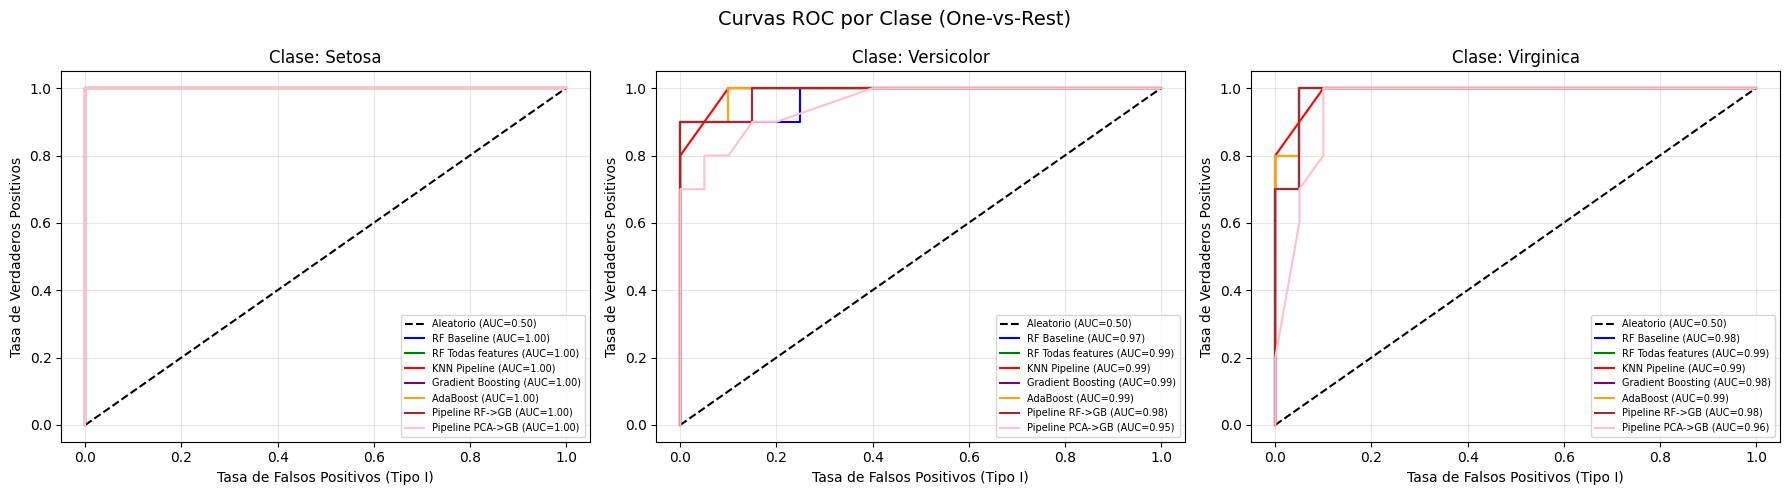

In [28]:
# Binarizamos y_test: convierte [0,1,2] en una matriz de 0s y 1s por clase
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Modelos a comparar con sus respectivos conjuntos de test
modelos_roc = [
    ('RF Baseline',       rf_base,     X_te_orig),
    ('RF Todas features', rf_todas,    X_te_todas),
    ('KNN Pipeline',      pipe_knn,    X_te_orig),
    ('Gradient Boosting', gb,          X_te_todas),
    ('AdaBoost',          ada,         X_te_todas),
    ('Pipeline RF->GB',   gb_tuned,    X_te_top),
    ('Pipeline PCA->GB',  pipe_pca_gb, X_te_orig),
]

colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'pink']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Curvas ROC por Clase (One-vs-Rest)', fontsize=14)

for ax, class_idx, class_name in zip(axes, [0, 1, 2], CLASS_NAMES):
    # linea de referencia (clasificador aleatorio)
    ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC=0.50)')

    for (nombre, modelo, X_te), color in zip(modelos_roc, colors):
        # probabilidades para la clase actual
        proba = modelo.predict_proba(X_te)[:, class_idx]
        fpr, tpr, _ = roc_curve(y_test_bin[:, class_idx], proba)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=1.5, label=f'{nombre} (AUC={roc_auc:.2f})')

    ax.set_title(f'Clase: {class_name.capitalize()}')
    ax.set_xlabel('Tasa de Falsos Positivos (Tipo I)')
    ax.set_ylabel('Tasa de Verdaderos Positivos')
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- **Setosa**: AUC = 1.00 en todos los modelos — perfectamente separable, como vimos en el EDA.
- **Versicolor** y **Virginica**: AUC ligeramente menor por el solapamiento entre estas dos especies.

Todos los modelos logran un buen AUC, lo cual confirma que el dataset Iris es clasificable con alta confianza.

---
## 8. Tabla Comparativa Final

In [29]:
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('F1-macro', ascending=False).reset_index(drop=True)
df_resultados.index += 1

display(df_resultados)

,Modelo,Features,Nro. Features,Accuracy,F1-macro,T. train (ms),T. pred (ms),Interpretabilidad
1,RF Todas features,todas (15),15,0.9667,0.9666,52.3,2.634,Media
2,RF Solo petalo,petalo (4),4,0.9667,0.9666,49.8,1.946,Media
3,Gradient Boosting,todas (15),15,0.9667,0.9666,124.5,1.813,Baja
4,Pipeline RF->GB (tuneado),top features (9),9,0.9667,0.9666,134.0,1.839,Baja
5,RF Orig + Ratios,originales + ratios (6),6,0.9333,0.9333,49.0,1.945,Media
6,AdaBoost,todas (15),15,0.9333,0.9333,56.7,3.942,Baja
7,XGBoost,todas (15),15,0.9333,0.9333,76.6,1.626,Baja
8,KNN Pipeline (k=5),originales (4),4,0.9333,0.9327,1.6,2.665,Alta
9,RF Baseline,originales (4),4,0.9000,0.8997,51.2,1.981,Media
10,Pipeline PCA->GB,PCA 2 componentes,2,0.8667,0.8667,156.1,1.142,Muy baja


**Interpretabilidad:**
- **Alta**: el modelo es directamente interpretable (KNN, binarias).
- **Media**: se puede analizar con importancia de features (Random Forest).
- **Baja**: modelo de tipo caja negra (Boosting).
- **Muy baja**: las features son componentes principales sin interpretación directa (PCA + modelo).

**Conclusión:** En Iris todos los modelos alcanzan buen rendimiento porque el dataset es pequeño, limpio y balanceado. Las diferencias se notan más en **interpretabilidad, cantidad de features necesarias y tiempo de entrenamiento**.